In [6]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import combine_pvalues, spearmanr
from statsmodels.stats.multitest import multipletests
from statsmodels.nonparametric.smoothers_lowess import lowess
import seaborn as sns
import shutil

# --- Set up Paths ---
expr_path = "/n/groups/patel/adithya/CellMatrix_with_genenames.parquet"
meta_path = "/n/groups/patel/adithya/New_CellMetadataSyn1848517.parquet"
output_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/"
os.makedirs(output_path, exist_ok=True)

# --- Load Data ---
meta_df = pd.read_parquet(meta_path)
meta_df['AD'] = meta_df['dcfdx_lv'].isin([4.0, 5.0]).map({True: 'AD', False: 'Control'}).astype('category')
print("AD status defined based on 'dcfdx':")
print(meta_df['AD'].value_counts())

expr_df = pd.read_parquet(expr_path)
expr_df.set_index('index', inplace=True)
expr_df_transposed = expr_df.T

# --- Analysis Settings ---
all_subclusters = meta_df['Subcluster'].unique()
# all_subclusters = ['Ex6']  # Uncomment to test single subcluster

random_seeds = [41, 42, 43]
# 57, 62, 72, 73

validation_results = []
summary_roc_data = []
summary_roc_data_cerad = []
roc_plot_data_cerad = []

# --- Main Loop ---
for current_subcluster in all_subclusters:
    print(f"\n--- Processing Subcluster: {current_subcluster} ---")

    meta_sub = meta_df[meta_df['Subcluster'] == current_subcluster]

    if meta_sub.shape[0] < 50 or len(meta_sub['AD'].unique()) < 2:
        print(f"Skipping {current_subcluster}: <50 cells or only one AD/Control group.")
        continue

    safe_subcluster_name = re.sub(r'[^a-zA-Z0-9_.-]', '_', current_subcluster)
    subcluster_cells = meta_sub['TAG'].tolist()
    expr_sub = expr_df_transposed.loc[subcluster_cells]

    # --- Create AnnData ---
    adata_template = sc.AnnData(X=expr_sub)
    adata_template.obs = meta_sub.set_index('TAG').loc[adata_template.obs.index]

    # --- NON-CIRCULAR: Use HVGs instead of DEGs ---
    print("Selecting HVGs for pseudotime (non-circular approach)...")
    sc.pp.normalize_total(adata_template, target_sum=1e4)
    sc.pp.log1p(adata_template)
    
    # Select top 2000 HVGs (or all genes if fewer available)
    n_top = min(2000, adata_template.n_vars - 1)
    sc.pp.highly_variable_genes(adata_template, n_top_genes=n_top, flavor='seurat')
    hvg_genes = adata_template.var[adata_template.var['highly_variable']].index.tolist()

    if len(hvg_genes) < 50:
        print(f"Skipping {current_subcluster}: only {len(hvg_genes)} HVGs found.")
        continue

    adata_template = adata_template[:, hvg_genes].copy()
    print(f"Using {len(hvg_genes)} HVGs to build trajectories.")

    # --- PCA (no Harmony - not needed within subclusters) ---
    n_pcs = min(30, len(hvg_genes) - 1)
    sc.pp.pca(adata_template, n_comps=n_pcs)
    print(f"PCA complete: {adata_template.obsm['X_pca'].shape}")

    # --- FAST neighbor graph ---
    print(f"Building neighbor graph for {adata_template.n_obs} cells...")
    sc.pp.neighbors(adata_template, n_neighbors=10, n_pcs=n_pcs, method='umap')
    print("Neighbor graph complete!")

    # --- Downstream: UMAP, clustering, diffusion map ---
    sc.tl.umap(adata_template)
    sc.tl.leiden(adata_template, resolution=0.5)
    sc.tl.diffmap(adata_template)

    # --- Loop over random seeds to test trajectory robustness ---
    subcluster_aucs = []
    roc_plot_data = []
    top_trajectory_genes_from_gt = []  # will be filled after seed loop

    subcluster_pvals, subcluster_odds_ratios = [], []
    all_fprs, all_tprs = [], []  # For mean ROC over seeds

    cerad_aucs = []
    cerad_odds_ratios = []
    cerad_pvals = []
    cerad_or_cis = []

    # Store pseudotime per seed (for later averaging)
    pseudotime_per_seed = []

    for seed in random_seeds:
        print(f"\n  -- Running analysis for seed: {seed} --")
        
        # Create a fresh copy for each run
        adata = adata_template.copy()

        # --- Select Root Cell Based on ceradsc and cogdx (with current seed) ---
        subcluster_meta_dpt = adata.obs.copy()
        subcluster_meta_dpt['ceradsc'] = pd.to_numeric(subcluster_meta_dpt['ceradsc'], errors='coerce')
        subcluster_meta_dpt['cogdx'] = pd.to_numeric(subcluster_meta_dpt['cogdx'], errors='coerce')
        subcluster_meta_dpt.dropna(subset=['ceradsc', 'cogdx'], inplace=True)
        
        if subcluster_meta_dpt.empty:
            print("  Skipping trajectory ordering: No cells with valid ceradsc/cogdx values.")
            break

        max_ceradsc = subcluster_meta_dpt['ceradsc'].max()
        root_candidates = subcluster_meta_dpt[subcluster_meta_dpt['ceradsc'] == max_ceradsc]
        min_cogdx = root_candidates['cogdx'].min()
        root_candidates = root_candidates[root_candidates['cogdx'] == min_cogdx]
        
        root_cell_id = root_candidates.sample(n=1, random_state=seed).index[0]
        adata.uns['iroot'] = np.where(adata.obs_names == root_cell_id)[0][0]

        # --- Calculate Pseudotime (DPT) ---
        sc.tl.dpt(adata)

        # Store pseudotime for this seed (full vector, all cells)
        pseudotime_per_seed.append(adata.obs['dpt_pseudotime'].to_numpy())

        # --- Calculate AUC for the current seed ---
        validation_df = adata.obs[['dpt_pseudotime', 'AD']].copy()
        validation_df.dropna(subset=['dpt_pseudotime'], inplace=True)
        y_true = (validation_df['AD'] == 'AD').astype(int)
        y_score = validation_df['dpt_pseudotime']
        
        auc_score = roc_auc_score(y_true=y_true, y_score=y_score)
        subcluster_aucs.append(auc_score)
        print(f"  --> Seed {seed}: AUC = {auc_score:.4f}")

        # Logistic regression for this seed
        X = sm.add_constant(validation_df['dpt_pseudotime'])
        if len(y_true.unique()) < 2:
            print(f"  Skipping seed {seed}: only one class present after dropping NaNs.")
            continue
            
        log_reg = sm.Logit(y_true, X).fit(disp=0)
        subcluster_pvals.append(log_reg.pvalues['dpt_pseudotime'])
        subcluster_odds_ratios.append(np.exp(log_reg.params['dpt_pseudotime']))

        # ROC curve for this seed (clinical AD)
        fpr, tpr, _ = roc_curve(y_true=y_true, y_score=y_score)
        all_fprs.append(fpr)
        all_tprs.append(tpr)

        if auc_score > 0.55:
            roc_plot_data.append({'fpr': fpr, 'tpr': tpr, 'auc': auc_score, 'seed': seed})

        # CERAD-based classifier
        try:
            cerad_df = adata.obs[['dpt_pseudotime']].copy()
            cerad_df['TAG'] = cerad_df.index

            meta_subset = meta_df[['TAG', 'ceradsc']].dropna()
            meta_subset['ceradsc'] = pd.to_numeric(meta_subset['ceradsc'], errors='coerce')

            cerad_df = cerad_df.merge(meta_subset, on="TAG", how="left")
            cerad_df = cerad_df.dropna(subset=["ceradsc", "dpt_pseudotime"])
            cerad_df['AD_cerad'] = cerad_df['ceradsc'].isin([1, 2]).astype(int)

            if cerad_df['AD_cerad'].nunique() < 2:
                print(f"  CERAD classifier skipped for seed {seed}: only one class present.")
            else:
                X_cerad = sm.add_constant(cerad_df['dpt_pseudotime'])
                y_cerad = cerad_df['AD_cerad']
                cerad_model = sm.Logit(y_cerad, X_cerad).fit(disp=0)

                cerad_auc = roc_auc_score(y_cerad, cerad_df['dpt_pseudotime'])
                cerad_or = np.exp(cerad_model.params['dpt_pseudotime'])
                cerad_p = cerad_model.pvalues['dpt_pseudotime']
                cerad_conf = cerad_model.conf_int().loc['dpt_pseudotime']
                cerad_or_lower = np.exp(cerad_conf[0])
                cerad_or_upper = np.exp(cerad_conf[1])

                cerad_aucs.append(cerad_auc)
                cerad_odds_ratios.append(cerad_or)
                cerad_pvals.append(cerad_p)
                cerad_or_cis.append((cerad_or_lower, cerad_or_upper))

                fpr_cerad, tpr_cerad, _ = roc_curve(y_cerad, cerad_df['dpt_pseudotime'])

                if cerad_auc > 0.55:
                    roc_plot_data_cerad.append({
                        'fpr': fpr_cerad,
                        'tpr': tpr_cerad,
                        'auc': cerad_auc,
                        'seed': seed
                    })

                print(f"  CERAD AUC (seed {seed}): {cerad_auc:.3f}")
        except Exception as e:
            print(f"  CERAD model failed for seed {seed}: {e}")

    # --- After all seeds are run, aggregate results and create combined outputs ---
    if not subcluster_aucs:
        print(f"No valid results generated for {current_subcluster}. Skipping final aggregation.")
        continue

    # === 1) Aggregate pseudotime across seeds (Option A: rank-normalized) ===
    if pseudotime_per_seed:
        pseudo_array = np.column_stack(pseudotime_per_seed)  # cells x n_seeds_used
        n_cells, n_seeds_used = pseudo_array.shape
        ranked = np.zeros_like(pseudo_array, dtype=float)

        for j in range(n_seeds_used):
            col = pseudo_array[:, j]
            valid = ~np.isnan(col)
            ranks = np.empty_like(col, dtype=float)
            ranks[~valid] = np.nan

            # rank 0..(n_valid-1)
            valid_vals = col[valid]
            order = np.argsort(valid_vals)
            rank_values = np.empty_like(order, dtype=float)
            rank_values[order] = np.arange(len(order), dtype=float)

            ranks[valid] = rank_values
            denom = max(len(order) - 1, 1)
            ranked[:, j] = ranks / denom

        mean_pseudotime = np.nanmean(ranked, axis=1)
        adata_template.obs['mean_pseudotime'] = mean_pseudotime
        adata_template.obs['TAG'] = adata_template.obs.index

        # --- Save GAM input using mean pseudotime ---
        gam_df = adata_template.obs[['projid', 'AD', 'TAG']].copy()
        gam_df['AD_binary'] = (gam_df['AD'] == 'AD').astype(int)
        gam_df['dpt_pseudotime'] = mean_pseudotime
        gam_df = gam_df.dropna(subset=['projid', 'AD_binary', 'TAG', 'dpt_pseudotime'])
        gam_df.to_csv(os.path.join(output_path, f"pseudotime_gam_input_{safe_subcluster_name}.csv"), index=False)

        # === 2) PC selection by correlation with mean pseudotime ===
        pc_scores = adata_template.obsm['X_pca'][:, :n_pcs]  # cells x PCs
        pc_correlations = []
        for k in range(pc_scores.shape[1]):
            rho, _ = spearmanr(pc_scores[:, k], mean_pseudotime)
            pc_correlations.append(rho)
        best_pc = int(np.nanargmax(np.abs(pc_correlations)))

        # "Average" gene loadings across seeds (PCA is shared; average = original)
        loadings_matrix = adata_template.varm['PCs']  # genes x PCs
        avg_loadings = loadings_matrix[:, best_pc]

        # all_pc_genes_df.to_csv(os.path.join(output_path, f"all_pc_loadings_{safe_subcluster_name}.csv"), index=False)

        top_idx = np.argsort(np.abs(avg_loadings))[::-1][:10]
        top_trajectory_genes_from_gt = adata_template.var_names[top_idx].tolist()
        print(f"  Top trajectory-informing genes (PC{best_pc + 1}): {top_trajectory_genes_from_gt}")

        top_50 = np.argsort(np.abs(avg_loadings))[::-1][:50]
        top_50_trajectory_genes_from_gt = adata_template.var_names[top_50].tolist()

        # --- Save top 50 gene loadings in rank order ---
        top50_df = pd.DataFrame({
            'rank': np.arange(1, 51),
            'gene': adata_template.var_names[top_50],
            'loading': avg_loadings[top_50],
            'abs_loading': np.abs(avg_loadings[top_50])
        })

        # Save to subcluster-specific CSV
        top50_path = os.path.join(output_path, f"top50_PC_loadings_{safe_subcluster_name}.csv")
        top50_df.to_csv(top50_path, index=False)
        print(f"Saved top-50 PC loadings → {top50_path}")
    
        # === 3a) UMAP plot colored by mean pseudotime ===
        plot_filename_umap = os.path.join(output_path, f"umap_pseudotime_{safe_subcluster_name}.png")
        sc.pl.umap(
            adata_template,
            color='mean_pseudotime',
            title=f'{current_subcluster}: Mean Pseudotime Trajectory',
            show=False,
            save=f"_{safe_subcluster_name}_umap.png",
            cmap="viridis"
        )
        shutil.move(f'figures/umap_{safe_subcluster_name}_umap.png', plot_filename_umap)

        # === 3b) Smoothed expression of top genes vs mean pseudotime ===
        if top_trajectory_genes_from_gt:
            fig, ax = plt.subplots(figsize=(10, 6))
            genes_to_plot = top_trajectory_genes_from_gt[:4]
            colors = sns.color_palette("colorblind", n_colors=len(genes_to_plot))

            pseudo_vals = mean_pseudotime
            valid_idx = ~np.isnan(pseudo_vals)
            sorted_idx = np.argsort(pseudo_vals[valid_idx])

            for gene, color in zip(genes_to_plot, colors):
                expr_vals = adata_template[:, gene].X
                # Handle sparse
                if not isinstance(expr_vals, np.ndarray):
                    expr_vals = expr_vals.toarray()
                expr_vals = np.asarray(expr_vals).flatten()

                expr_valid = expr_vals[valid_idx][sorted_idx]
                pseudo_sorted = pseudo_vals[valid_idx][sorted_idx]

                smoothed = lowess(expr_valid, pseudo_sorted, frac=0.3)
                smoothed_z = (smoothed[:, 1] - smoothed[:, 1].mean()) / smoothed[:, 1].std()
                ax.plot(smoothed[:, 0], smoothed_z, label=gene, color=color)

            ax.set_xlabel('Mean Pseudotime (rank-normalized)')
            ax.set_ylabel('Z-scored Expression')
            ax.set_title(f'{current_subcluster}: Smoothed Expression of Top Genes')
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            fig.savefig(os.path.join(output_path, f"lineplot_top_genes_{safe_subcluster_name}.png"),
                        bbox_inches='tight')
            plt.close(fig)

    # === Aggregate CERAD stats across seeds ===
    if cerad_aucs:
        mean_auc_cerad = np.mean(cerad_aucs)
        se_auc_cerad = np.std(cerad_aucs, ddof=1) / np.sqrt(len(cerad_aucs))
        auc_cerad_ci = (mean_auc_cerad - 1.96 * se_auc_cerad, mean_auc_cerad + 1.96 * se_auc_cerad)

        log_cerad_ors = np.log(cerad_odds_ratios)
        mean_log_or_cerad = np.mean(log_cerad_ors)
        se_log_or_cerad = np.std(log_cerad_ors, ddof=1) / np.sqrt(len(log_cerad_ors))
        or_cerad_ci = (
            np.exp(mean_log_or_cerad - 1.96 * se_log_or_cerad),
            np.exp(mean_log_or_cerad + 1.96 * se_log_or_cerad)
        )
        mean_or_cerad = np.exp(mean_log_or_cerad)

        _, combined_p_cerad = combine_pvalues(cerad_pvals, method='fisher')

        print(f"  CERAD mean AUC: {mean_auc_cerad:.3f} (95% CI: {auc_cerad_ci[0]:.3f}–{auc_cerad_ci[1]:.3f})")
        print(f"  CERAD mean OR: {mean_or_cerad:.2f} (95% CI: {or_cerad_ci[0]:.2f}–{or_cerad_ci[1]:.2f}), p={combined_p_cerad:.3g}")

        if mean_auc_cerad > 0.55:
            mean_fpr_cerad = np.linspace(0, 1, 100)
            interp_tprs_cerad = []

            for data in roc_plot_data_cerad:
                interp_tprs_cerad.append(np.interp(mean_fpr_cerad, data['fpr'], data['tpr']))

            mean_tpr_cerad = np.mean(interp_tprs_cerad, axis=0)
            mean_tpr_cerad[0], mean_tpr_cerad[-1] = 0, 1

            summary_roc_data_cerad.append({
                'fpr': mean_fpr_cerad,
                'tpr': mean_tpr_cerad,
                'Subcluster': current_subcluster,
                'mean_auc': mean_auc_cerad,
                'se_auc': se_auc_cerad
            })
    else:
        mean_auc_cerad = np.nan
        auc_cerad_ci = (np.nan, np.nan)
        mean_or_cerad = np.nan
        or_cerad_ci = (np.nan, np.nan)
        combined_p_cerad = np.nan

    # === Aggregate clinical AD stats across seeds ===
    mean_auc = np.mean(subcluster_aucs)
    se_auc = np.std(subcluster_aucs, ddof=1) / np.sqrt(len(subcluster_aucs))
    auc_ci_95 = (mean_auc - 1.96 * se_auc, mean_auc + 1.96 * se_auc)
    
    log_ors = np.log(subcluster_odds_ratios)
    mean_log_or = np.mean(log_ors)
    se_log_or = np.std(log_ors, ddof=1) / np.sqrt(len(log_ors))
    log_or_ci_95 = (mean_log_or - 1.96 * se_log_or, mean_log_or + 1.96 * se_log_or)
    mean_or = np.exp(mean_log_or)
    or_ci_95 = (np.exp(log_or_ci_95[0]), np.exp(log_or_ci_95[1]))

    _, combined_p_value = combine_pvalues(subcluster_pvals, method='fisher')
    
    print(f"\n--- Aggregated Results for {current_subcluster} ---")
    print(f"Mean AUC: {mean_auc:.4f} (95% CI: {auc_ci_95[0]:.4f} - {auc_ci_95[1]:.4f})")
    print(f"Mean Odds Ratio: {mean_or:.4f} (95% CI: {or_ci_95[0]:.4f} - {or_ci_95[1]:.4f})")
    print(f"Combined P-value (Fisher's): {combined_p_value:.4g}")

    # === Mean ROC curve across seeds for this subcluster ===
    if mean_auc > 0.55:
        mean_fpr = np.linspace(0, 1, 100)
        interp_tprs = []
        for fpr, tpr in zip(all_fprs, all_tprs):
            interp_tprs.append(np.interp(mean_fpr, fpr, tpr))
        
        if interp_tprs:
            mean_tpr = np.mean(interp_tprs, axis=0)
            mean_tpr[0], mean_tpr[-1] = 0, 1
            
            summary_roc_data.append({
                'fpr': mean_fpr,
                'tpr': mean_tpr,
                'Subcluster': current_subcluster,
                'mean_auc': mean_auc,
                'se_auc': se_auc
            })


    # Store per-subcluster summary row
    validation_results.append({
        'Subcluster': current_subcluster,
        'mean_auc': mean_auc,
        'auc_ci_lower': auc_ci_95[0],
        'auc_ci_upper': auc_ci_95[1],
        'mean_odds_ratio': mean_or,
        'or_ci_lower': or_ci_95[0],
        'or_ci_upper': or_ci_95[1],
        'combined_p_value': combined_p_value,
        'mean_auc_cerad': mean_auc_cerad,
        'auc_cerad_lower': auc_cerad_ci[0],
        'auc_cerad_upper': auc_cerad_ci[1],
        'odds_ratio_cerad': mean_or_cerad,
        'or_cerad_lower': or_cerad_ci[0],
        'or_cerad_upper': or_cerad_ci[1],
        'p_value_cerad': combined_p_cerad,
        'n_cells': adata_template.n_obs,
        'top_trajectory_genes': ', '.join(top_trajectory_genes_from_gt) if top_trajectory_genes_from_gt else "N/A",
        'top_pc_loadings': ', '.join(top_50_trajectory_genes_from_gt) if top_50_trajectory_genes_from_gt else "N/A",
    })

# --- Save Final Aggregated Validation Results ---
if not validation_results:
    print("\nNo subclusters were successfully processed. Exiting.")
else:
    validation_summary_df = pd.DataFrame(validation_results).sort_values(by='mean_auc', ascending=False)
    
    # FDR correction for clinical AD
    if 'combined_p_value' in validation_summary_df.columns:
        pvals = validation_summary_df['combined_p_value'].dropna()
        if not pvals.empty:
            reject, q_values, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
            validation_summary_df['fdr_q_value'] = np.nan
            validation_summary_df.loc[pvals.index, 'fdr_q_value'] = q_values
    
    # FDR correction for CERAD
    if 'p_value_cerad' in validation_summary_df.columns:
        cerad_pvals = validation_summary_df['p_value_cerad'].dropna()
        if not cerad_pvals.empty:
            _, cerad_qvals, _, _ = multipletests(cerad_pvals, alpha=0.05, method='fdr_bh')
            validation_summary_df['fdr_q_value_cerad'] = np.nan
            validation_summary_df.loc[cerad_pvals.index, 'fdr_q_value_cerad'] = cerad_qvals

    validation_summary_path = os.path.join(output_path, "publication_summary_statistics.csv")
    validation_summary_df.to_csv(validation_summary_path, index=False)
    print(f"\nFinal publication-ready summary saved to: {validation_summary_path}")

    # === Final combined ROC plot for clinical AD (only subclusters with mean AUC > 0.55) ===
    if summary_roc_data:
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(10, 8))
        
        summary_roc_data.sort(key=lambda x: x['mean_auc'], reverse=True)
        
        for data in summary_roc_data:
            ax.plot(
                data['fpr'], data['tpr'],
                label=f"{data['Subcluster']} (AUC = {data['mean_auc']:.3f} \u00B1 {data['se_auc']:.3f})"
            )

        ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
        ax.set_xlabel('False Positive Rate', fontsize=14)
        ax.set_ylabel('True Positive Rate', fontsize=14)
        ax.set_title('Clinical AD ROC Curves using Disease Trajectory', fontsize=16)
        ax.legend(loc='lower right', frameon=True, fontsize=10)
        plt.savefig(os.path.join(output_path, "summary_roc_plot_all_subclusters.png"),
                    bbox_inches='tight', dpi=300)
        plt.close(fig)
        print(f"Saved summary ROC plot to: {os.path.join(output_path, 'summary_roc_plot_all_subclusters.png')}")

    # === Final combined ROC plot for CERAD (only subclusters with mean AUC > 0.55) ===
    if summary_roc_data_cerad:
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(10, 8))

        summary_roc_data_cerad.sort(key=lambda x: x['mean_auc'], reverse=True)

        for data in summary_roc_data_cerad:
            ax.plot(
                data['fpr'], data['tpr'],
                label=f"{data['Subcluster']} (AUC = {data['mean_auc']:.3f} ± {data['se_auc']:.3f})"
            )

        ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
        ax.set_xlabel('False Positive Rate', fontsize=14)
        ax.set_ylabel('True Positive Rate', fontsize=14)
        ax.set_title('Pathological AD ROC Curves using Disease Trajectory (CERAD)', fontsize=16)
        ax.legend(loc='lower right', frameon=True, fontsize=10)
        plt.savefig(os.path.join(output_path, "summary_roc_plot_CERAD_all_subclusters.png"),
                    bbox_inches='tight', dpi=300)
        plt.close(fig)
        print("Saved CERAD summary ROC plot to: summary_roc_plot_CERAD_all_subclusters.png")

print("\n--- Analysis complete. ---")
print("\n--- Pseudotime robustness analysis complete for all subclusters. ---")

AD status defined based on 'dcfdx':
AD
Control    39202
AD         31432
Name: count, dtype: int64

--- Processing Subcluster: Ex8 ---
Selecting HVGs for pseudotime (non-circular approach)...
Using 2000 HVGs to build trajectories.
PCA complete: (1828, 30)
Building neighbor graph for 1828 cells...
Neighbor graph complete!

  -- Running analysis for seed: 41 --
  --> Seed 41: AUC = 0.5094
  CERAD AUC (seed 41): 0.514

  -- Running analysis for seed: 42 --
  --> Seed 42: AUC = 0.5116
  CERAD AUC (seed 42): 0.506

  -- Running analysis for seed: 43 --
  --> Seed 43: AUC = 0.4884
  CERAD AUC (seed 43): 0.506
  Top trajectory-informing genes (PC1): ['NEFL', 'NEFM', 'CLU', 'TUBB2A', 'HSP90AA1', 'FTH1', 'STMN1', 'UBB', 'PCSK1N', 'NDUFA4']
Saved top-50 PC loadings → /n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/top50_PC_loadings_Ex8.csv
  CERAD mean AUC: 0.509 (95% CI: 0.504–0.513)
  CERAD mean OR: 0.93 (95% CI: 0.88–0.99), p=0.981

--- Aggregated Results for Ex8 ---
Mean AUC: 0.5031 (95

/tmp/ipykernel_3264070/3336996490.py:317: RuntimeWarning: invalid value encountered in divide
  smoothed_z = (smoothed[:, 1] - smoothed[:, 1].mean()) / smoothed[:, 1].std()


  CERAD mean AUC: 0.498 (95% CI: 0.496–0.499)
  CERAD mean OR: 1.05 (95% CI: 1.04–1.06), p=0.998

--- Aggregated Results for In10 ---
Mean AUC: 0.5051 (95% CI: 0.5034 - 0.5067)
Mean Odds Ratio: 1.2371 (95% CI: 1.2290 - 1.2453)
Combined P-value (Fisher's): 0.8354

--- Processing Subcluster: In5 ---
Selecting HVGs for pseudotime (non-circular approach)...
Using 2000 HVGs to build trajectories.
PCA complete: (548, 30)
Building neighbor graph for 548 cells...
Neighbor graph complete!

  -- Running analysis for seed: 41 --
  --> Seed 41: AUC = 0.5792
  CERAD AUC (seed 41): 0.539

  -- Running analysis for seed: 42 --
  --> Seed 42: AUC = 0.5010
  CERAD AUC (seed 42): 0.468

  -- Running analysis for seed: 43 --
  --> Seed 43: AUC = 0.4894
  CERAD AUC (seed 43): 0.459
  Top trajectory-informing genes (PC2): ['NRG1', 'RELN', 'KCNIP4', 'C8orf34', 'TMEFF2', 'CDH13', 'ZBTB20', 'ASIC2', 'SORCS3', 'NEGR1']
Saved top-50 PC loadings → /n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/top50_PC_loa

In [3]:
# === Check in how many subclusters LINGO1 or RASGEF1B appear as trajectory-influencing genes ===

import pandas as pd
import os

summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"

print("\n=== Checking trajectory selection frequency for LINGO1 and RASGEF1B ===")

# Load the summary table generated by the pseudotime pipeline
df = pd.read_csv(summary_path)

# Extract the list column into python lists
df['top_trajectory_genes_list'] = df['top_trajectory_genes'].fillna("").apply(
    lambda x: [gene.strip() for gene in x.split(",")] if isinstance(x, str) else []
)

genes_of_interest = ["LINGO1", "RASGEF1B", "APOE", "CLU", "GFAP"]

# Track counts
gene_counts = {g: 0 for g in genes_of_interest}
subclusters_per_gene = {g: [] for g in genes_of_interest}

for _, row in df.iterrows():
    genes = row['top_trajectory_genes_list']
    subcluster = row['Subcluster']
    
    for g in genes_of_interest:
        if g in genes:
            gene_counts[g] += 1
            subclusters_per_gene[g].append(subcluster)

# Print results
print("\n=== Results ===")
for g in genes_of_interest:
    print(f"{g}: selected as top trajectory gene in {gene_counts[g]} subclusters")
    if gene_counts[g] > 0:
        print(f"  Subclusters: {subclusters_per_gene[g]}")


=== Checking trajectory selection frequency for LINGO1 and RASGEF1B ===

=== Results ===
LINGO1: selected as top trajectory gene in 3 subclusters
  Subclusters: ['Ex3', 'Opc0', 'Ast1']
RASGEF1B: selected as top trajectory gene in 5 subclusters
  Subclusters: ['Ex14', 'Ex3', 'Ex0', 'In7', 'Ast1']
APOE: selected as top trajectory gene in 2 subclusters
  Subclusters: ['Ast0', 'Ast1']
CLU: selected as top trajectory gene in 2 subclusters
  Subclusters: ['Ex11', 'Ex8']
GFAP: selected as top trajectory gene in 1 subclusters
  Subclusters: ['Ast1']


In [16]:
# # === Check in how many subclusters the genes appear among the TOP 50 PC loading genes ===

# import pandas as pd
# import os

# summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"

# print("\n=== Checking TOP-50 PC loading frequency for target genes ===")

# # Load the summary table generated by the pseudotime pipeline
# df = pd.read_csv(summary_path)

# # Extract the top-50 list column into python lists
# df['top50_gene_list'] = df['top_pc_loadings'].fillna("").apply(
#     lambda x: [gene.strip() for gene in x.split(",")] if isinstance(x, str) else []
# )

# # Genes to check
# genes_of_interest = ["LINGO1", "RASGEF1B", "APOE", "CLU", "GFAP", "CRYAB", "APOD", "SRGN"]

# # Track counts
# gene_counts = {g: 0 for g in genes_of_interest}
# subclusters_per_gene = {g: [] for g in genes_of_interest}

# # Loop through subclusters
# for _, row in df.iterrows():
#     genes = row['top50_gene_list']
#     subcluster = row['Subcluster']
    
#     for g in genes_of_interest:
#         if g in genes:
#             gene_counts[g] += 1
#             subclusters_per_gene[g].append(subcluster)

# # Print the results
# print("\n=== Results: Presence in TOP 50 Loadings ===")
# for g in genes_of_interest:
#     print(f"{g}: present in top-50 loading genes for {gene_counts[g]} subclusters")
#     if gene_counts[g] > 0:
#         print(f"  Subclusters: {subclusters_per_gene[g]}")


=== Checking TOP-50 PC loading frequency for target genes ===

=== Results: Presence in TOP 50 Loadings ===
LINGO1: present in top-50 loading genes for 12 subclusters
  Subclusters: ['Opc1', 'Ast0', 'Ex14', 'Ex3', 'Oli1', 'Ex8', 'Ex0', 'Opc0', 'In4', 'In7', 'In11', 'Ast1']
RASGEF1B: present in top-50 loading genes for 18 subclusters
  Subclusters: ['Oli3', 'Opc1', 'Ast0', 'Oli0', 'In0', 'In5', 'Ex14', 'Ex3', 'Oli1', 'Ex8', 'Ex0', 'Mic0', 'In4', 'Ex2', 'In7', 'Ex1', 'In8', 'Ast1']
APOE: present in top-50 loading genes for 3 subclusters
  Subclusters: ['Mic1', 'Ast0', 'Ast1']
CLU: present in top-50 loading genes for 5 subclusters
  Subclusters: ['Ex11', 'Per', 'Ex8', 'Ex0', 'Ex6']
GFAP: present in top-50 loading genes for 2 subclusters
  Subclusters: ['Ast2', 'Ast1']
CRYAB: present in top-50 loading genes for 6 subclusters
  Subclusters: ['Oli3', 'Ast2', 'Oli0', 'Oli1', 'In10', 'Oli5']
APOD: present in top-50 loading genes for 2 subclusters
  Subclusters: ['Oli3', 'Opc1']
SRGN: present 

In [ ]:
# # === Check in how many subclusters the genes appear among the TOP 20 PC loading genes ===

# import pandas as pd
# import os

# summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"

# print("\n=== Checking TOP-20 PC loading frequency for target genes ===")

# # Load the summary table generated by the pseudotime pipeline
# df = pd.read_csv(summary_path)

# # Extract the top-20 list column into python lists
# df['top20_gene_list'] = df['top_pc_loadings'].fillna("").apply(
#     lambda x: [gene.strip() for gene in x.split(",")[:20]] if isinstance(x, str) else []
# )

# # Genes to check
# genes_of_interest = ["LINGO1", "RASGEF1B", "APOE", "CLU", "GFAP", "CRYAB", "APOD", "SRGN"]

# # Track counts
# gene_counts = {g: 0 for g in genes_of_interest}
# subclusters_per_gene = {g: [] for g in genes_of_interest}

# # Loop through subclusters
# for _, row in df.iterrows():
#     genes = row['top20_gene_list']
#     subcluster = row['Subcluster']
    
#     for g in genes_of_interest:
#         if g in genes:
#             gene_counts[g] += 1
#             subclusters_per_gene[g].append(subcluster)

# # Print the results
# print("\n=== Results: Presence in TOP 20 Loadings ===")
# for g in genes_of_interest:
#     print(f"{g}: present in top-20 loading genes for {gene_counts[g]} subclusters")
#     if gene_counts[g] > 0:
#         print(f"  Subclusters: {subclusters_per_gene[g]}")


=== Checking TOP-20 PC loading frequency for target genes ===

=== Results: Presence in TOP 20 Loadings ===
LINGO1: present in top-20 loading genes for 9 subclusters
  Subclusters: ['Opc1', 'Ex14', 'Ex3', 'Ex8', 'Ex0', 'Opc0', 'In4', 'In11', 'Ast1']
RASGEF1B: present in top-20 loading genes for 6 subclusters
  Subclusters: ['Oli3', 'Ex14', 'Ex3', 'Ex0', 'In7', 'Ast1']
APOE: present in top-20 loading genes for 2 subclusters
  Subclusters: ['Ast0', 'Ast1']
CLU: present in top-20 loading genes for 2 subclusters
  Subclusters: ['Ex11', 'Ex8']
GFAP: present in top-20 loading genes for 1 subclusters
  Subclusters: ['Ast1']
CRYAB: present in top-20 loading genes for 3 subclusters
  Subclusters: ['Oli3', 'Ast2', 'Oli1']
APOD: present in top-20 loading genes for 2 subclusters
  Subclusters: ['Oli3', 'Opc1']
SRGN: present in top-20 loading genes for 0 subclusters


In [4]:
# # === Check in how many subclusters key genes appear as trajectory-influencing genes ===

# import pandas as pd
# import os

# summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"

# print("\n=== Checking trajectory selection frequency for key genes ===")

# # Load summary table
# df = pd.read_csv(summary_path)

# # Extract the list column into python lists
# df['top_trajectory_genes_list'] = df['top_trajectory_genes'].fillna("").apply(
#     lambda x: [gene.strip() for gene in x.split(",")] if isinstance(x, str) else []
# )

# genes_of_interest = ["LINGO1", "RASGEF1B", "APOE", "CLU", "GFAP"]

# # Track counts
# gene_counts = {g: 0 for g in genes_of_interest}
# subclusters_per_gene = {g: [] for g in genes_of_interest}

# for _, row in df.iterrows():
#     top_genes = row['top_trajectory_genes_list']
#     all_loadings = str(row.get('all_pc_loadings', ''))
#     subcluster = row['Subcluster']

#     for g in genes_of_interest:
#         # Present in top 10?
#         in_top = g in top_genes
        
#         # Present anywhere in the full PC loadings string?
#         in_loadings = f"{g}:" in all_loadings

#         if in_top or in_loadings:
#             gene_counts[g] += 1
#             subclusters_per_gene[g].append(subcluster)

# # Print results
# print("\n=== Results ===")
# for g in genes_of_interest:
#     print(f"{g}: present in trajectory PC for {gene_counts[g]} subclusters")
#     if gene_counts[g] > 0:
#         print(f"  Subclusters: {subclusters_per_gene[g]}")


=== Checking trajectory selection frequency for key genes ===

=== Results ===
LINGO1: present in trajectory PC for 31 subclusters
  Subclusters: ['Ex11', 'Opc1', 'Ast0', 'In0', 'In5', 'Ex14', 'Ex3', 'In9', 'Oli1', 'In3', 'Ex9', 'Ex8', 'Ex0', 'In2', 'Opc0', 'Ex12', 'Ex6', 'In4', 'In7', 'Oli5', 'Ex5', 'Oli4', 'Ex1', 'In6', 'In8', 'In1', 'Ex7', 'Mic3', 'In11', 'Ast1', 'Ex4']
RASGEF1B: present in trajectory PC for 38 subclusters
  Subclusters: ['Oli3', 'Ast2', 'Ex11', 'Per', 'Opc1', 'Ast0', 'Oli0', 'In0', 'In5', 'Ex14', 'Ex3', 'In9', 'Oli1', 'In10', 'In3', 'Ex9', 'Ex8', 'Ex0', 'In2', 'Mic0', 'Opc0', 'Ex12', 'Ex6', 'In4', 'Ex2', 'In7', 'Oli5', 'Ex5', 'Oli4', 'Ex1', 'In6', 'In8', 'In1', 'Ex7', 'Mic3', 'In11', 'Ast1', 'Ex4']
APOE: present in trajectory PC for 19 subclusters
  Subclusters: ['Mic1', 'Per', 'Opc2', 'Opc1', 'Ast0', 'Oli0', 'In0', 'In5', 'Ex3', 'In9', 'Mic2', 'Oli1', 'In10', 'Ex0', 'Mic0', 'Ex1', 'In6', 'Ex7', 'Ast1']
CLU: present in trajectory PC for 14 subclusters
  Subcluster

In [2]:
# === Check in how many subclusters key genes appear as trajectory-influencing genes ===

import pandas as pd

summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"

print("\n=== Checking trajectory selection frequency for key genes ===")

df = pd.read_csv(summary_path)

# Parse trajectory gene lists
df['top_trajectory_genes_list'] = df['top_trajectory_genes'].fillna("").apply(
    lambda x: [g.strip() for g in x.split(",")] if isinstance(x, str) else []
)

genes_of_interest = ["LINGO1", "RASGEF1B", "APOE", "CLU", "GFAP", "SRGN", "APOD"]

def count_presence(top_k):
    gene_counts = {g: 0 for g in genes_of_interest}
    subclusters_per_gene = {g: [] for g in genes_of_interest}

    for _, row in df.iterrows():
        subcluster = row['Subcluster']
        top_genes = row['top_trajectory_genes_list'][:top_k]

        for g in genes_of_interest:
            if g in top_genes:
                gene_counts[g] += 1
                subclusters_per_gene[g].append(subcluster)

    return gene_counts, subclusters_per_gene


# --- TOP 10 ---
# counts_10, subs_10 = count_presence(top_k=10)

# print("\n=== TOP 10 trajectory genes ===")
# for g in genes_of_interest:
#     print(f"{g}: present in {counts_10[g]} subclusters")
#     if counts_10[g] > 0:
#         print(f"  Subclusters: {subs_10[g]}")


# --- TOP 20 ---
counts_20, subs_20 = count_presence(top_k=20)

print("\n=== TOP 20 trajectory genes ===")
for g in genes_of_interest:
    print(f"{g}: present in {counts_20[g]} subclusters")
    if counts_20[g] > 0:
        print(f"  Subclusters: {subs_20[g]}")


=== Checking trajectory selection frequency for key genes ===

=== TOP 20 trajectory genes ===
LINGO1: present in 3 subclusters
  Subclusters: ['Ex3', 'Opc0', 'Ast1']
RASGEF1B: present in 5 subclusters
  Subclusters: ['Ex14', 'Ex3', 'Ex0', 'In7', 'Ast1']
APOE: present in 2 subclusters
  Subclusters: ['Ast0', 'Ast1']
CLU: present in 2 subclusters
  Subclusters: ['Ex11', 'Ex8']
GFAP: present in 1 subclusters
  Subclusters: ['Ast1']
SRGN: present in 0 subclusters
APOD: present in 2 subclusters
  Subclusters: ['Oli3', 'Opc1']


In [5]:
# print("\n=== Counting how many genes are in the top PC component per subcluster ===")

# genes_in_pc_count = {}

# for _, row in df.iterrows():
#     subcluster = row['Subcluster']
#     load_str = str(row.get("all_pc_loadings", ""))

#     if load_str.strip() == "":
#         genes_in_pc_count[subcluster] = 0
#         continue

#     # Count gene:loading entries
#     pairs = [p for p in load_str.split(";") if ":" in p]
#     genes_in_pc_count[subcluster] = len(pairs)

# # Print results
# for subcluster, count in genes_in_pc_count.items():
#     print(f"{subcluster}: {count} genes in the top-PC loadings")

# print("\n=== Summary statistics ===")
# counts = list(genes_in_pc_count.values())
# print(f"Mean genes per top PC: {np.mean(counts):.1f}")
# print(f"Median: {np.median(counts):.1f}")
# print(f"Min: {np.min(counts)}")
# print(f"Max: {np.max(counts)}")


=== Counting how many genes are in the top PC component per subcluster ===
Oli3: 2000 genes in the top-PC loadings
Ast2: 2000 genes in the top-PC loadings
Ex11: 2000 genes in the top-PC loadings
Mic1: 2000 genes in the top-PC loadings
Per: 2002 genes in the top-PC loadings
Opc2: 2006 genes in the top-PC loadings
End1: 2000 genes in the top-PC loadings
Opc1: 2000 genes in the top-PC loadings
Ast0: 2000 genes in the top-PC loadings
Oli0: 2000 genes in the top-PC loadings
In0: 2000 genes in the top-PC loadings
In5: 2000 genes in the top-PC loadings
Ex14: 2000 genes in the top-PC loadings
Ex3: 2000 genes in the top-PC loadings
In9: 2000 genes in the top-PC loadings
Mic2: 2010 genes in the top-PC loadings
Oli1: 2000 genes in the top-PC loadings
In10: 2000 genes in the top-PC loadings
In3: 2000 genes in the top-PC loadings
Ex9: 2000 genes in the top-PC loadings
Ex8: 2000 genes in the top-PC loadings
Ex0: 2000 genes in the top-PC loadings
In2: 2000 genes in the top-PC loadings
Mic0: 2000 gen

In [16]:
# === Identify genes appearing in the largest number of subclusters ===

import pandas as pd
import os
from collections import Counter

summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG/publication_summary_statistics.csv"

print("\n=== Identifying genes that appear most often as top trajectory-influencing genes ===")

# Load summary table
df = pd.read_csv(summary_path)

# Extract list of genes per subcluster
df['top_trajectory_genes_list'] = df['top_trajectory_genes'].fillna("").apply(
    lambda x: [gene.strip() for gene in x.split(",")] if isinstance(x, str) else []
)

# Count how many subclusters each gene appears in
gene_to_count = Counter()
gene_to_subclusters = {}

for _, row in df.iterrows():
    genes = row['top_trajectory_genes_list']
    subcluster = row['Subcluster']

    for gene in genes:
        if gene == "N/A" or gene.strip() == "":
            continue

        gene_to_count[gene] += 1

        if gene not in gene_to_subclusters:
            gene_to_subclusters[gene] = []
        gene_to_subclusters[gene].append(subcluster)

# Sort by descending frequency
sorted_genes = gene_to_count.most_common()

# Print the top genes (top 20 by default)
top_n = 20
print(f"\n=== Top {top_n} most frequent trajectory-influencing genes ===")
for gene, count in sorted_genes[:top_n]:
    print(f"{gene}: {count} subclusters")
    print(f"  Subclusters: {gene_to_subclusters.get(gene, [])}")


=== Identifying genes that appear most often as top trajectory-influencing genes ===

=== Top 20 most frequent trajectory-influencing genes ===
NKAIN2: 7 subclusters
  Subclusters: ['Ex11', 'Oli0', 'In0', 'In9', 'Oli1', 'Ex2', 'Oli5']
GPC6: 6 subclusters
  Subclusters: ['Opc1', 'In0', 'Ex14', 'Ex0', 'Opc0', 'In11']
KCNIP4: 6 subclusters
  Subclusters: ['In5', 'In9', 'In4', 'In7', 'In8', 'In1']
HSP90AA1: 5 subclusters
  Subclusters: ['Oli3', 'Ex8', 'Ex1', 'Mic3', 'Ast1']
FTH1: 5 subclusters
  Subclusters: ['Mic1', 'Ast0', 'Oli1', 'Ex8', 'Ast1']
LRP1B: 5 subclusters
  Subclusters: ['Oli0', 'In2', 'Ex2', 'Oli5', 'Ex5']
TMEFF2: 5 subclusters
  Subclusters: ['Oli0', 'In5', 'Oli5', 'Ex5', 'Oli4']
SGCZ: 5 subclusters
  Subclusters: ['In0', 'Ex3', 'In3', 'Opc0', 'In8']
NRG1: 5 subclusters
  Subclusters: ['In5', 'Ex9', 'Ex6', 'In8', 'Ex4']
RASGEF1B: 5 subclusters
  Subclusters: ['Ex14', 'Ex3', 'Ex0', 'In7', 'Ast1']
NCAM2: 5 subclusters
  Subclusters: ['In9', 'In4', 'In7', 'Ex5', 'Oli4']
PTPRT:

In [3]:
# === Identify most recurrent trajectory-influencing gene per CELL TYPE ===

import pandas as pd
from collections import Counter, defaultdict
import re

summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"

print("\n=== Identifying top recurrent trajectory gene per cell type ===")

# ----------------------------
# Load summary table
# ----------------------------
df = pd.read_csv(summary_path)

# Parse top-trajectory genes (TOP 20 assumed)
df['top_trajectory_genes_list'] = df['top_trajectory_genes'].fillna("").apply(
    lambda x: [g.strip() for g in x.split(",") if g.strip() not in ["", "N/A"]]
)

# ----------------------------
# Helper: extract cell type from subcluster name
# Assumes subclusters like Ast0, Mic3, Ex14, etc.
# ----------------------------
def get_cell_type(subcluster):
    match = re.match(r"^[A-Za-z]+", str(subcluster))
    return match.group(0) if match else None

df['cell_type'] = df['Subcluster'].apply(get_cell_type)

# ----------------------------
# Aggregate by cell type
# ----------------------------
celltype_gene_counts = defaultdict(Counter)
celltype_gene_subclusters = defaultdict(lambda: defaultdict(list))

for _, row in df.iterrows():
    ct = row['cell_type']
    sub = row['Subcluster']
    genes = row['top_trajectory_genes_list']

    if ct is None or not genes:
        continue

    for g in genes:
        celltype_gene_counts[ct][g] += 1
        celltype_gene_subclusters[ct][g].append(sub)

# ----------------------------
# Report top gene per cell type
# ----------------------------
print("\n=== Most recurrent TOP-20 trajectory gene per cell type ===")

results = []

for ct in sorted(celltype_gene_counts.keys()):
    top_gene, count = celltype_gene_counts[ct].most_common(1)[0]
    subclusters = celltype_gene_subclusters[ct][top_gene]

    print(f"\n{ct}:")
    print(f"  Top gene: {top_gene}")
    print(f"  Appears in {count} subclusters")
    print(f"  Subclusters: {subclusters}")

    results.append({
        "cell_type": ct,
        "top_trajectory_gene": top_gene,
        "n_subclusters": count,
        "subclusters": ", ".join(subclusters)
    })

# ----------------------------
# Save table (publication-ready)
# ----------------------------
out_df = pd.DataFrame(results)
out_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/top_trajectory_gene_per_cell_type.csv"
out_df.to_csv(out_path, index=False)

print(f"\nSaved summary → {out_path}")


=== Identifying top recurrent trajectory gene per cell type ===

=== Most recurrent TOP-20 trajectory gene per cell type ===

Ast:
  Top gene: FTH1
  Appears in 2 subclusters
  Subclusters: ['Ast0', 'Ast1']

End:
  Top gene: PDE4D
  Appears in 1 subclusters
  Subclusters: ['End1']

Ex:
  Top gene: ROBO2
  Appears in 3 subclusters
  Subclusters: ['Ex11', 'Ex7', 'Ex4']

In:
  Top gene: KCNIP4
  Appears in 6 subclusters
  Subclusters: ['In5', 'In9', 'In4', 'In7', 'In8', 'In1']

Mic:
  Top gene: FTL
  Appears in 1 subclusters
  Subclusters: ['Mic1']

Oli:
  Top gene: NKAIN2
  Appears in 3 subclusters
  Subclusters: ['Oli0', 'Oli1', 'Oli5']

Opc:
  Top gene: CNTNAP2
  Appears in 2 subclusters
  Subclusters: ['Opc2', 'Opc0']

Per:
  Top gene: TRPM3
  Appears in 1 subclusters
  Subclusters: ['Per']

Saved summary → /n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/top_trajectory_gene_per_cell_type.csv


=== Identifying genes that appear most often as top trajectory-influencing genes ===

=== Top 20 most frequent trajectory-influencing genes ===
NKAIN2: 7 subclusters
  Subclusters: ['Ex11', 'Oli0', 'In0', 'In9', 'Oli1', 'Ex2', 'Oli5']
GPC6: 6 subclusters
  Subclusters: ['Opc1', 'In0', 'Ex14', 'Ex0', 'Opc0', 'In11']
KCNIP4: 6 subclusters
  Subclusters: ['In5', 'In9', 'In4', 'In7', 'In8', 'In1']
HSP90AA1: 5 subclusters
  Subclusters: ['Oli3', 'Ex8', 'Ex1', 'Mic3', 'Ast1']
FTH1: 5 subclusters
  Subclusters: ['Mic1', 'Ast0', 'Oli1', 'Ex8', 'Ast1']
LRP1B: 5 subclusters
  Subclusters: ['Oli0', 'In2', 'Ex2', 'Oli5', 'Ex5']
TMEFF2: 5 subclusters
  Subclusters: ['Oli0', 'In5', 'Oli5', 'Ex5', 'Oli4']
SGCZ: 5 subclusters
  Subclusters: ['In0', 'Ex3', 'In3', 'Opc0', 'In8']
NRG1: 5 subclusters
  Subclusters: ['In5', 'Ex9', 'Ex6', 'In8', 'Ex4']
RASGEF1B: 5 subclusters
  Subclusters: ['Ex14', 'Ex3', 'Ex0', 'In7', 'Ast1']
NCAM2: 5 subclusters
  Subclusters: ['In9', 'In4', 'In7', 'Ex5', 'Oli4']
PTPRT: 5 subclusters
  Subclusters: ['In3', 'Ex9', 'Ex6', 'In4', 'Ex4']
ROBO2: 4 subclusters
  Subclusters: ['Ex11', 'In0', 'Ex7', 'Ex4']
CNTN5: 4 subclusters
  Subclusters: ['Ex11', 'In2', 'Ex12', 'In1']
PDZRN4: 4 subclusters
  Subclusters: ['Opc1', 'Opc0', 'Ex5', 'Ex7']
NTM: 4 subclusters
  Subclusters: ['Oli0', 'Ex14', 'Oli5', 'Ex1']
DHFR: 4 subclusters
  Subclusters: ['Ex14', 'Ex3', 'In11', 'Ex4']
LRRC4C: 4 subclusters
  Subclusters: ['Ex14', 'Ex0', 'In4', 'Ex4']
CRYAB: 3 subclusters
  Subclusters: ['Oli3', 'Ast2', 'Oli1']
FTL: 3 subclusters
  Subclusters: ['Oli3', 'Mic1', 'Ast0']

=== Identifying genes that appear most often as top trajectory-influencing genes ===

=== Top 20 most frequent trajectory-influencing genes ===
NKAIN2: 7 subclusters
  Subclusters: ['Ex11', 'Oli0', 'In0', 'In9', 'Oli1', 'Ex2', 'Oli5']
GPC6: 6 subclusters
  Subclusters: ['Opc1', 'In0', 'Ex14', 'Ex0', 'Opc0', 'In11']
KCNIP4: 6 subclusters
  Subclusters: ['In5', 'In9', 'In4', 'In7', 'In8', 'In1']
HSP90AA1: 5 subclusters
  Subclusters: ['Oli3', 'Ex8', 'Ex1', 'Mic3', 'Ast1']
FTH1: 5 subclusters
  Subclusters: ['Mic1', 'Ast0', 'Oli1', 'Ex8', 'Ast1']
LRP1B: 5 subclusters
  Subclusters: ['Oli0', 'In2', 'Ex2', 'Oli5', 'Ex5']
TMEFF2: 5 subclusters
  Subclusters: ['Oli0', 'In5', 'Oli5', 'Ex5', 'Oli4']
SGCZ: 5 subclusters
  Subclusters: ['In0', 'Ex3', 'In3', 'Opc0', 'In8']
NRG1: 5 subclusters
  Subclusters: ['In5', 'Ex9', 'Ex6', 'In8', 'Ex4']
RASGEF1B: 5 subclusters
  Subclusters: ['Ex14', 'Ex3', 'Ex0', 'In7', 'Ast1']
NCAM2: 5 subclusters
  Subclusters: ['In9', 'In4', 'In7', 'Ex5', 'Oli4']
PTPRT: 5 subclusters
  Subclusters: ['In3', 'Ex9', 'Ex6', 'In4', 'Ex4']
ROBO2: 4 subclusters
  Subclusters: ['Ex11', 'In0', 'Ex7', 'Ex4']
CNTN5: 4 subclusters
  Subclusters: ['Ex11', 'In2', 'Ex12', 'In1']
PDZRN4: 4 subclusters
  Subclusters: ['Opc1', 'Opc0', 'Ex5', 'Ex7']
NTM: 4 subclusters
  Subclusters: ['Oli0', 'Ex14', 'Oli5', 'Ex1']
DHFR: 4 subclusters
  Subclusters: ['Ex14', 'Ex3', 'In11', 'Ex4']
LRRC4C: 4 subclusters
  Subclusters: ['Ex14', 'Ex0', 'In4', 'Ex4']
CRYAB: 3 subclusters
  Subclusters: ['Oli3', 'Ast2', 'Oli1']
FTL: 3 subclusters
  Subclusters: ['Oli3', 'Mic1', 'Ast0']

In [11]:
import pandas as pd

# Load saved summary
summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"
df = pd.read_csv(summary_path)

# Extract cell type from subcluster name
df['cell_type'] = df['Subcluster'].str.extract(r'^([A-Za-z]+)')

# Thresholds to evaluate
AUC_THRESHOLDS = [0.60, 0.55, 0.50]

for thr in AUC_THRESHOLDS:
    print("\n" + "="*70)
    print(f"AUC THRESHOLD > {thr}")
    print("="*70)

    # =================================================
    # Clinical AD
    # =================================================
    clinical = df[df['mean_auc'] > thr]

    print("\n[Clinical AD]")
    print(f"Predictive subclusters: {clinical.shape[0]}")
    print(f"Predictive cell types: {clinical['cell_type'].nunique()}")

    if not clinical.empty:
        print("\nSubclusters with effect sizes:")
        for _, row in clinical.iterrows():
            print(
                f"  {row['Subcluster']} "
                f"(cell type: {row['cell_type']}, "
                f"AUC={row['mean_auc']:.3f}, "
                f"OR={row['mean_odds_ratio']:.2f} "
                f"[{row['or_ci_lower']:.2f}–{row['or_ci_upper']:.2f}])"
            )

        print("\nGrouped by cell type:")
        print(
            clinical.groupby('cell_type')['Subcluster']
            .apply(list)
        )

    # =================================================
    # CERAD neuropathology
    # =================================================
    cerad = df[df['mean_auc_cerad'] > thr]

    print("\n[CERAD neuropathology]")
    print(f"Predictive subclusters: {cerad.shape[0]}")
    print(f"Predictive cell types: {cerad['cell_type'].nunique()}")

    if not cerad.empty:
        print("\nSubclusters with effect sizes:")
        for _, row in cerad.iterrows():
            print(
                f"  {row['Subcluster']} "
                f"(cell type: {row['cell_type']}, "
                f"AUC={row['mean_auc_cerad']:.3f}, "
                f"OR={row['odds_ratio_cerad']:.2f} "
                f"[{row['or_cerad_lower']:.2f}–{row['or_cerad_upper']:.2f}])"
            )

        print("\nGrouped by cell type:")
        print(
            cerad.groupby('cell_type')['Subcluster']
            .apply(list)
        )


AUC THRESHOLD > 0.6

[Clinical AD]
Predictive subclusters: 2
Predictive cell types: 2

Subclusters with effect sizes:
  Oli3 (cell type: Oli, AUC=0.699, OR=54.19 [39.98–73.46])
  Ast2 (cell type: Ast, AUC=0.623, OR=22.22 [4.99–98.97])

Grouped by cell type:
cell_type
Ast    [Ast2]
Oli    [Oli3]
Name: Subcluster, dtype: object

[CERAD neuropathology]
Predictive subclusters: 2
Predictive cell types: 2

Subclusters with effect sizes:
  Oli3 (cell type: Oli, AUC=0.714, OR=76.26 [50.09–116.11])
  Opc2 (cell type: Opc, AUC=0.654, OR=161.18 [0.71–36618.77])

Grouped by cell type:
cell_type
Oli    [Oli3]
Opc    [Opc2]
Name: Subcluster, dtype: object

AUC THRESHOLD > 0.55

[Clinical AD]
Predictive subclusters: 7
Predictive cell types: 7

Subclusters with effect sizes:
  Oli3 (cell type: Oli, AUC=0.699, OR=54.19 [39.98–73.46])
  Ast2 (cell type: Ast, AUC=0.623, OR=22.22 [4.99–98.97])
  Ex11 (cell type: Ex, AUC=0.578, OR=6.99 [2.31–21.14])
  Mic1 (cell type: Mic, AUC=0.577, OR=0.55 [0.22–1.37])


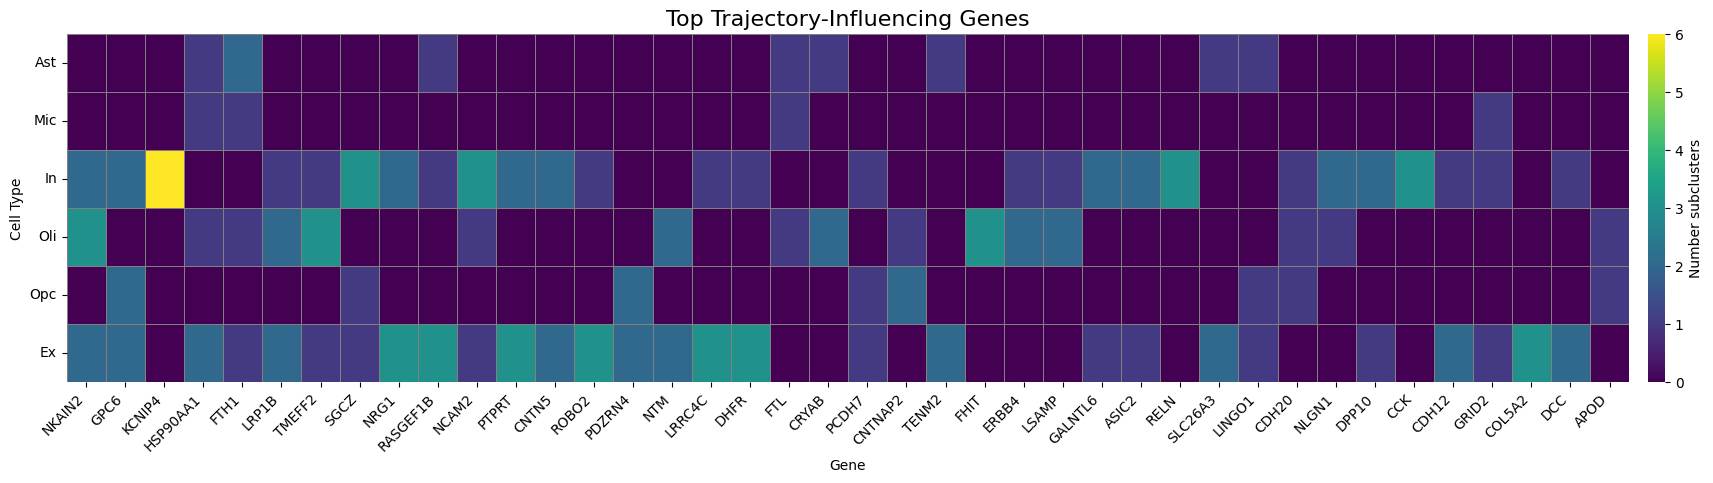

Saved trajectory heatmap → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/heatmap_top40_trajectory_genes_celltype.png


In [6]:
# ============================================================
# Cell-type × Top Trajectory-Influencing Genes Heatmap
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re
import os

# =========================
# Paths
# =========================
summary_path = "/n/groups/patel/adithya/Pseudotime_Outputs_HVG_final/publication_summary_statistics.csv"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "heatmap_top40_trajectory_genes_celltype.png")

# =========================
# Parameters
# =========================
TOP_K = 20        # top genes per subcluster
TOP_N_GENES = 40  # global top genes to plot
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]  # drop "Other"

# =========================
# Load
# =========================
df = pd.read_csv(summary_path)

# =========================
# Helpers
# =========================
def parse_gene_list(x):
    if not isinstance(x, str):
        return []
    return [g.strip() for g in x.split(",") if g.strip() not in ["", "N/A", "nan", "None"]]

def get_cell_type(subcluster):
    m = re.match(r"^[A-Za-z]+", str(subcluster))
    return m.group(0) if m else None

# =========================
# Parse TOP-20 per subcluster
# =========================
df["cell_type"] = df["Subcluster"].apply(get_cell_type)
df = df[df["cell_type"].isin(cell_types)].copy()

df["top_genes_full"] = df["top_trajectory_genes"].apply(parse_gene_list)
df["top_genes_topk"] = df["top_genes_full"].apply(lambda L: L[:TOP_K])
df = df[df["top_genes_topk"].apply(len) > 0]

# =========================
# Global frequency: gene → # subclusters (TOP-20 membership)
# =========================
gene_to_subcluster_count = defaultdict(int)

for _, row in df.iterrows():
    for g in set(row["top_genes_topk"]):
        gene_to_subcluster_count[g] += 1

# Select top 40 genes globally
top_genes = [
    g for g, _ in sorted(
        gene_to_subcluster_count.items(),
        key=lambda kv: kv[1],
        reverse=True
    )[:TOP_N_GENES]
]

# =========================
# Build cell_type × gene matrix
# =========================
gene_celltype_counts = defaultdict(lambda: defaultdict(int))

for _, row in df.iterrows():
    ct = row["cell_type"]
    for g in set(row["top_genes_topk"]):
        if g in top_genes:
            gene_celltype_counts[ct][g] += 1

heatmap_df = (
    pd.DataFrame(gene_celltype_counts)
    .T
    .fillna(0)
    .astype(int)
)

# Enforce row / column order
heatmap_df = heatmap_df.reindex(cell_types)
heatmap_df = heatmap_df[top_genes]

# Sort genes by total recurrence
heatmap_df = heatmap_df[
    heatmap_df.sum(axis=0).sort_values(ascending=False).index
]

# =========================
# Plot (PP.H4-style)
# =========================
plt.figure(figsize=(24, 6))

sns.heatmap(
    heatmap_df,
    cmap="viridis",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": f"Number subclusters", "pad": 0.01},
    vmin=0
)

plt.title("Top Trajectory-Influencing Genes", fontsize=16)
plt.xlabel("Gene")
plt.ylabel("Cell Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.subplots_adjust(bottom=0.3)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved trajectory heatmap → {out_path}")